# Optimizing a stellarator geometry from VMEC++

This notebook links to VMEC++ directly by default. `VmecppGeometryProvider` loads the installed named W7-X input, runs `vmecpp.run` in memory, and maps the resulting field line without writing or reading a geometry file. A `wout` interoperability path and synthetic fallback remain explicit options.

> The current VMEC++ provider is intentionally non-differentiable. A real example script, `examples/vmecpp_w7x_design_loop.py`, implements central differences across fresh VMEC++ solves.

## How the coupled calculation works

`VMEC boundary Fourier coefficients` → `vmecpp.run` → force-balanced equilibrium → field-line reconstruction from `wout` → `VmecppGeometryProvider` → physical field/metric arrays → provider-neutral `GeometryResult` → internal normalized geometry → linear gyrokinetic evolution → growth/frequency/mode structure/quasilinear proxy → objective and constraints → outer optimizer.

VMEC++ and the GK solver are linked as libraries in one Python loop; files are optional interchange/cache artifacts, not the conceptual interface. The optimizer must also see VMEC convergence, aspect ratio, coil/curvature proxies, stability constraints, and bounds—not only a turbulence proxy.

In [1]:
import os
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jax_fluxtube_gk import (
    DesignObjectiveSpec, FourierGridSpec, GeometryRequest, OptimizationKnobs,
    SingleSurfaceOptimizationConfig, SyntheticGeometryProvider, VelocityGridSpec,
    VmecppGeometryProvider, assert_fixed_optimization_topology, build_fourier_grid,
    build_mode_connectivity, build_optimization_topology_contract,
    build_velocity_grid, design_objective, internal_geometry_from_result,
    k_perp_squared, resolve_geometry,
)

jax.config.update("jax_enable_x64", True)

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
GEOMETRY_SOURCE = "provider"  # provider | wout | synthetic
VMECPP_WOUT = os.environ.get("VMECPP_WOUT")

In [2]:
def vmecpp_boundary_xyz(vmec_input, n_theta=60, n_zeta=200):
    """Reconstruct the stellarator-symmetric VMEC boundary from rbc/zbs Fourier
    coefficients and return Cartesian (X, Y, Z) surface grids of shape (n_theta, n_zeta)."""
    rbc = np.asarray(vmec_input.rbc, dtype=float)
    zbs = np.asarray(vmec_input.zbs, dtype=float)
    ntor = int(vmec_input.ntor)
    nfp = int(vmec_input.nfp)
    m = np.arange(rbc.shape[0])
    n = np.arange(-ntor, ntor + 1) * nfp
    theta = np.linspace(0.0, 2 * np.pi, n_theta, endpoint=True)
    zeta = np.linspace(0.0, 2 * np.pi, n_zeta, endpoint=True)
    theta_g, zeta_g = np.meshgrid(theta, zeta, indexing="ij")
    arg = (
        m[:, None, None, None] * theta_g[None, None, :, :]
        - n[None, :, None, None] * zeta_g[None, None, :, :]
    )
    R = np.einsum("mn,mnij->ij", rbc, np.cos(arg))
    Z = np.einsum("mn,mnij->ij", zbs, np.sin(arg))
    return R * np.cos(zeta_g), R * np.sin(zeta_g), Z


def plot_boundary_surface(ax, X, Y, Z, **kwargs):
    """Render a stellarator boundary surface with a physically equal-aspect, angled view."""
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, linewidth=0, antialiased=True, **kwargs)
    span = max(X.max() - X.min(), Y.max() - Y.min(), Z.max() - Z.min())
    ax.set_box_aspect(((X.max() - X.min()) / span, (Y.max() - Y.min()) / span, (Z.max() - Z.min()) / span))
    ax.view_init(elev=35, azim=45)
    ax.set_axis_off()

In [3]:
request = GeometryRequest(
    configuration="w7x-standard", radial_value=0.8, alpha=0.0, n_z=32,
    z_min=-np.pi, z_max=np.pi, field_periods=1.0,
)
if GEOMETRY_SOURCE == "provider":
    provider = VmecppGeometryProvider(max_threads=1, revision="record-your-revision")
elif GEOMETRY_SOURCE == "wout":
    if not VMECPP_WOUT:
        raise RuntimeError("Set VMECPP_WOUT when GEOMETRY_SOURCE='wout'")
    provider = VmecppGeometryProvider(wout_path=VMECPP_WOUT)
elif GEOMETRY_SOURCE == "synthetic":
    provider = SyntheticGeometryProvider(magnetic_field_amplitude=0.18, iota=0.9, shear=0.2, nfp=5)
else:
    raise ValueError("GEOMETRY_SOURCE must be 'provider', 'wout', or 'synthetic'")
geometry_result = resolve_geometry(provider, request)
parallel = geometry_result.parallel_grid
geometry = internal_geometry_from_result(geometry_result)
metadata = geometry_result.metadata
print(f"provider={metadata.provenance.provider!r}, differentiable={metadata.differentiable}")
print(f"source={metadata.provenance.source}")

Running cmake --build & --install in /Users/mohsensadr/Codes/GitHub/fusion/vmecpp/build


error: /Applications/Xcode.app/Contents/Developer/Toolchains/XcodeDefault.xctoolchain/usr/bin/install_name_tool: no LC_RPATH load command with path: /opt/homebrew/lib found in: /Users/mohsensadr/Codes/GitHub/fusion/JAXFluxTubeGK/.venv/lib/python3.13/site-packages/vmecpp/cpp/./_vmecpp.cpython-313-darwin.so (for architecture arm64), required for specified option "-delete_rpath /opt/homebrew/lib"


provider='vmecpp', differentiable=False
source=installed VMEC++ named configuration w7x-standard


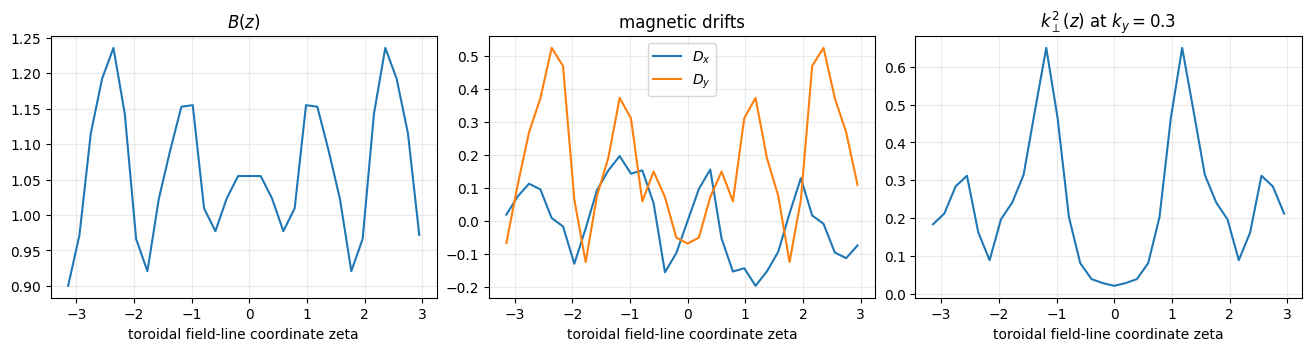

In [4]:
fourier = build_fourier_grid(FourierGridSpec(n_kx=1, n_ky=1, kx_max=0.0, ky_values=(0.3,)))
kp2 = np.asarray(k_perp_squared(geometry, fourier)).squeeze()
z = np.asarray(parallel.z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
axes[0].plot(z, np.asarray(geometry.B))
axes[0].set_title(r"$B(z)$")
axes[1].plot(z, np.asarray(geometry.D_x), label=r"$D_x$")
axes[1].plot(z, np.asarray(geometry.D_y), label=r"$D_y$")
axes[1].legend()
axes[1].set_title("magnetic drifts")
axes[2].plot(z, kp2)
axes[2].set_title(r"$k_\perp^2(z)$ at $k_y=0.3$")
for ax in axes:
    ax.set_xlabel("toroidal field-line coordinate zeta")
    ax.grid(alpha=0.25)
plt.show()

## Reduced gyrokinetic evaluation

The local solver never edits VMEC data. It consumes the normalized field-line coefficients, builds a distribution state on `(v_parallel, mu, z, kx, ky)`, advances the linear residual, obtains the electrostatic field response, and reports mode diagnostics. The objective contract can weight selected/worst/softmax growth, frequency mismatch, mode-shape mismatch, and a quasilinear proxy. Two time steps and one mode below are only a fast integration trace.

In [5]:
velocity = build_velocity_grid(VelocityGridSpec(n_vpar=2, n_mu=2, vpar_max=1.5, mu_max=1.0))
connectivity = build_mode_connectivity(fourier)
shape = (velocity.vpar.size, velocity.mu.size, parallel.z.size, 1, 1)
index = jnp.arange(np.prod(shape), dtype=jnp.float64).reshape(shape)
initial_state = 1e-2 * (jnp.cos(index / 7.0) + 1j * jnp.sin(index / 11.0))
spec = DesignObjectiveSpec(selected_ky=0, growth_weight=1.0)
config = SingleSurfaceOptimizationConfig(
    geometry_model="precomputed", dt=0.005, n_steps=2, selected_ky=0,
    objective_kind="selected_growth", store_history=False,
)

def gk_objective(local_geometry, temperature_gradient=2.1):
    return design_objective(
        OptimizationKnobs(density_gradient=0.8, temperature_gradient=temperature_gradient),
        velocity, parallel, fourier, initial_state, spec, connectivity=connectivity,
        config=config, geometry=local_geometry,
    )

result = gk_objective(geometry)
profile_grad = jax.grad(lambda a: gk_objective(geometry, a).scalar_objective)(jnp.array(2.1))
print(f"objective={float(result.scalar_objective): .6e}")
print(f"growth={float(result.selected_growth_rate): .6e}, frequency={float(result.selected_frequency): .6e}")
print(f"fixed-geometry d objective / d(R/L_T)={float(profile_grad): .6e}")

objective=-2.200674e-01
growth=-2.200674e-01, frequency= 1.157848e-01
fixed-geometry d objective / d(R/L_T)=-2.831499e-07


## Boundary-harmonic outer loop

For one real VMEC harmonic, copy the named input, scale `rbc[m, ntor+n]` and `zbs[m, ntor+n]`, run VMEC++, reconstruct geometry, and evaluate the GK objective. Central differences compare fresh solves at $p+h$ and $p-h$. Keep all grid sizes and solver controls fixed and call `assert_fixed_optimization_topology` before accepting a comparison.

The next cell is an executable **interface surrogate**, using cosine-$B$ amplitude and a geometric proxy so that the notebook needs no VMEC++ installation. The following cell gives the real call pattern.

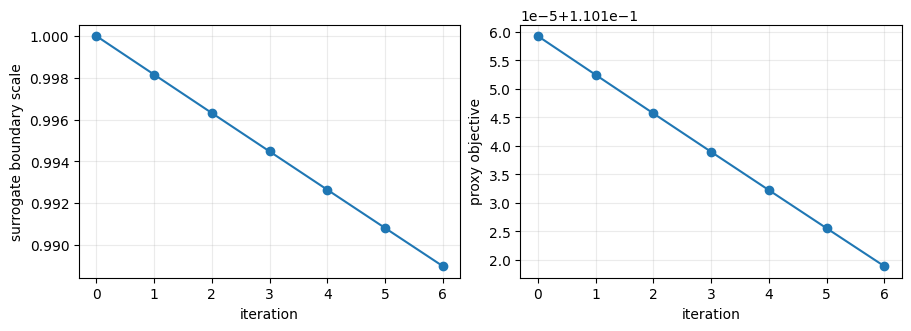

In [6]:
def surrogate_cost(boundary_scale):
    candidate = resolve_geometry(
        SyntheticGeometryProvider(magnetic_field_amplitude=0.18 * boundary_scale, iota=0.9, shear=0.2, nfp=5),
        request,
    )
    geom = internal_geometry_from_result(candidate)
    return float(jnp.mean(k_perp_squared(geom, fourier) / geom.B[:, None, None]))

scale, h, rate = 1.0, 1e-3, 0.5
history = []
for iteration in range(7):
    value = surrogate_cost(scale)
    gradient = (surrogate_cost(scale + h) - surrogate_cost(scale - h)) / (2 * h)
    history.append((iteration, scale, value, gradient))
    scale = float(np.clip(scale - rate * gradient, 0.8, 1.2))
history = np.asarray(history)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
axes[0].plot(history[:, 0], history[:, 1], "o-")
axes[0].set_ylabel("surrogate boundary scale")
axes[1].plot(history[:, 0], history[:, 2], "o-")
axes[1].set_ylabel("proxy objective")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.grid(alpha=0.25)
plt.show()

iteration 0: scale=1.000000 objective=-2.200674e-01 sensitivity=-3.259e-01


iteration 1: scale=1.003259 objective=-2.211202e-01 sensitivity=-3.178e-01


iteration 2: scale=1.006438 objective=-2.221166e-01 sensitivity=-3.097e-01


iteration 3: scale=1.009534 objective=-2.230682e-01 sensitivity=-3.061e-01


iteration 4: scale=1.012595 objective=-2.239832e-01 sensitivity=-2.963e-01


saved /Users/mohsensadr/Codes/GitHub/fusion/JAXFluxTubeGK/figures/vmecpp_boundary_evolution.png


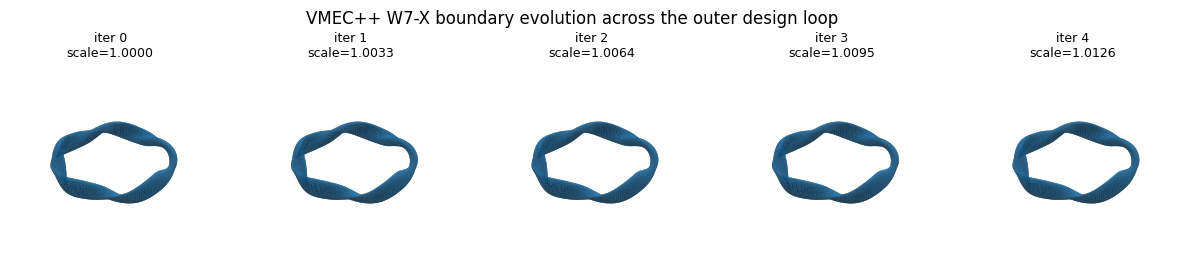

saved /Users/mohsensadr/Codes/GitHub/fusion/JAXFluxTubeGK/figures/vmecpp_initial_live_design_scan.png


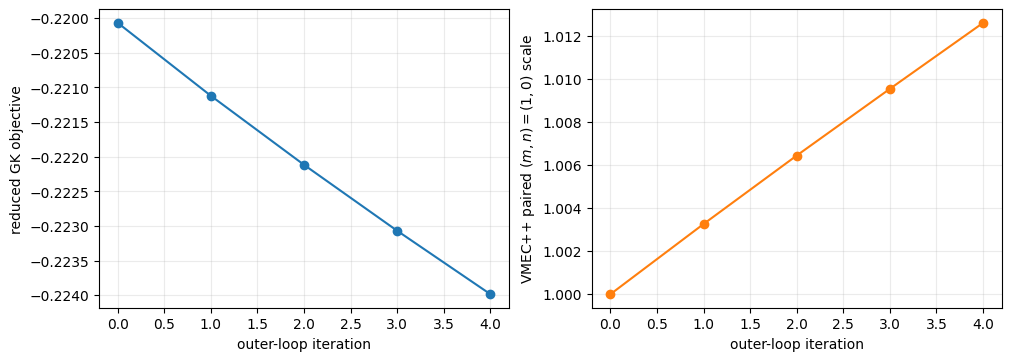

[{'scale': 1.0, 'rbc': 0.49093, 'zbs': 0.61965, 'objective': -0.22006742039692995, 'growth_rate': -0.22006742039692995, 'frequency': 0.11578481855072048, 'provider': 'vmecpp', 'iteration': 0, 'requested_scale': 1.0, 'sensitivity': -0.32594149027787345}, {'scale': 1.0032594149027787, 'rbc': 0.49253014455822114, 'zbs': 0.6216696964445069, 'objective': -0.2211202367187859, 'growth_rate': -0.2211202367187859, 'frequency': 0.1159462389763892, 'provider': 'vmecpp', 'iteration': 1, 'requested_scale': 1.0032594149027787, 'sensitivity': -0.3178366312159534}, {'scale': 1.0064377812149383, 'rbc': 0.49409049993184967, 'zbs': 0.6236391711298366, 'objective': -0.22211658138751034, 'growth_rate': -0.22211658138751034, 'frequency': 0.11610345533980257, 'provider': 'vmecpp', 'iteration': 2, 'requested_scale': 1.0064377812149383, 'sensitivity': -0.30966954116539314}, {'scale': 1.0095344766265923, 'rbc': 0.49561076061029297, 'zbs': 0.625558038441668, 'objective': -0.2230682191087574, 'growth_rate': -0.22

In [7]:
reference_topology = build_optimization_topology_contract(
    velocity, parallel, fourier, connectivity=connectivity,
    geometry_metadata=geometry_result.metadata,
)

def evaluate_live_vmecpp_design(boundary_scale, m=1, n=0):
    """Scale paired VMEC harmonics, run VMEC++, and evaluate reduced GK."""
    import copy

    import vmecpp

    vmec_input = copy.deepcopy(vmecpp.named_configuration("w7x-standard"))
    coefficient_index = int(vmec_input.ntor) + n
    reference_rbc = float(vmec_input.rbc[m, coefficient_index])
    reference_zbs = float(vmec_input.zbs[m, coefficient_index])
    vmec_input.rbc[m, coefficient_index] = boundary_scale * reference_rbc
    vmec_input.zbs[m, coefficient_index] = boundary_scale * reference_zbs
    candidate_result = resolve_geometry(
        VmecppGeometryProvider(
            vmec_input=vmec_input, runner=vmecpp.run, max_threads=1,
            revision="record-your-revision",
        ),
        request,
    )
    candidate_topology = build_optimization_topology_contract(
        velocity, candidate_result.parallel_grid, fourier, connectivity=connectivity,
        geometry_metadata=candidate_result.metadata,
    )
    assert_fixed_optimization_topology(reference_topology, candidate_topology)
    objective = gk_objective(internal_geometry_from_result(candidate_result))
    return {
        "scale": float(boundary_scale),
        "rbc": float(vmec_input.rbc[m, coefficient_index]),
        "zbs": float(vmec_input.zbs[m, coefficient_index]),
        "objective": float(objective.scalar_objective),
        "growth_rate": float(objective.selected_growth_rate),
        "frequency": float(objective.selected_frequency),
        "provider": candidate_result.metadata.provenance.provider,
        "vmec_input": vmec_input,
    }

if GEOMETRY_SOURCE == "provider":
    # Outer-loop hill-climb: at each iteration, take a real 3-point central-difference
    # sensitivity through fresh VMEC++ solves (as above), step the boundary scale, and
    # record the resulting real 3D boundary shape. This is still a reduced,
    # single-harmonic outer loop -- not a claim of unrestricted shape optimization.
    N_ITERATIONS = 5
    relative_step = 0.005
    learning_rate = 0.01
    scale_bounds = (0.98, 1.02)
    scale = 1.0
    history = []
    boundary_frames = []
    for iteration in range(N_ITERATIONS):
        design_scales = scale + scale * np.array([-relative_step, 0.0, relative_step])
        live_design = [evaluate_live_vmecpp_design(s) for s in design_scales]
        objectives = np.array([row["objective"] for row in live_design])
        sensitivity = float(
            (objectives[2] - objectives[0]) / (design_scales[2] - design_scales[0])
        )
        center = live_design[1]
        history.append(
            {key: value for key, value in center.items() if key != "vmec_input"}
            | {"iteration": iteration, "requested_scale": scale, "sensitivity": sensitivity}
        )
        boundary_frames.append((iteration, scale, vmecpp_boundary_xyz(center["vmec_input"])))
        print(
            f"iteration {iteration}: scale={scale:.6f} objective={center['objective']: .6e} "
            f"sensitivity={sensitivity: .3e}"
        )
        scale = float(np.clip(scale - learning_rate * sensitivity, *scale_bounds))

    fig = plt.figure(figsize=(3.0 * N_ITERATIONS, 3.2))
    for column, (iteration, iter_scale, (X, Y, Z)) in enumerate(boundary_frames):
        ax = fig.add_subplot(1, N_ITERATIONS, column + 1, projection="3d")
        plot_boundary_surface(ax, X, Y, Z, color="tab:blue", alpha=0.95)
        ax.set_title(f"iter {iteration}\nscale={iter_scale:.4f}", fontsize=9)
    fig.suptitle("VMEC++ W7-X boundary evolution across the outer design loop")
    boundary_figure_path = ROOT / "figures/vmecpp_boundary_evolution.png"
    fig.savefig(boundary_figure_path, dpi=150, bbox_inches="tight")
    print(f"saved {boundary_figure_path}")
    plt.show()

    iterations = np.array([row["iteration"] for row in history])
    scales = np.array([row["scale"] for row in history])
    objectives = np.array([row["objective"] for row in history])
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].plot(iterations, objectives, "o-")
    axes[0].set_ylabel("reduced GK objective")
    axes[1].plot(iterations, scales, "o-", color="tab:orange")
    axes[1].set_ylabel(r"VMEC++ paired $(m,n)=(1,0)$ scale")
    for ax in axes:
        ax.set_xlabel("outer-loop iteration")
        ax.grid(alpha=0.25)
    figure_path = ROOT / "figures/vmecpp_initial_live_design_scan.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    print(f"saved {figure_path}")
    plt.show()
    print(history)
else:
    print("Select GEOMETRY_SOURCE='provider' to run the live VMEC++ design scan.")

### From demonstration to useful optimization

Start with a handful of stellarator-symmetric harmonics and strict bounds. Evaluate multiple `(rho, alpha, ky)` samples, use mean-plus-worst-case aggregation, retain VMEC force-balance/convergence metrics, and cache each evaluation with provenance. Perform finite-difference step audits and higher-resolution rechecks. The standalone real loop can be run from the repository root with `uv run --extra dev --extra reference python examples/vmecpp_w7x_design_loop.py --iterations 2`.

![Initial live VMEC++ design sensitivity](../figures/vmecpp_initial_live_design_scan.png)

The real 3D boundary below is reconstructed directly from the same `rbc`/`zbs` Fourier coefficients scaled at each outer-loop iteration -- it is the exact fixed-boundary shape VMEC++ solved for, not a schematic.

![VMEC++ boundary evolution across the outer design loop](../figures/vmecpp_boundary_evolution.png)